In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
dataset=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Exploratory Data Analysis (EDA)

## 1. Dataset Overview

The dataset contains customer information from a telecommunications company and aims to predict customer churn.

### Dataset Characteristics

- Total Records: **7043**
- Total Features: **21**
- Target Variable: **Churn**
- Numerical Features:
  - tenure
  - MonthlyCharges
  - TotalCharges
- Categorical Features:
  - gender
  - SeniorCitizen
  - Partner
  - Dependents
  - PhoneService
  - MultipleLines
  - InternetService
  - OnlineSecurity
  - OnlineBackup
  - DeviceProtection
  - TechSupport
  - StreamingTV
  - StreamingMovies
  - Contract
  - PaperlessBilling
  - PaymentMethod
- Identifier Column:
  - customerID

The `customerID` column serves only as a unique identifier and does not provide predictive information.

---

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
dataset.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

In [6]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Missing Value Analysis

An initial missing value check indicated that the dataset contained no missing values.

However, further inspection revealed that the `TotalCharges` column was stored as an object datatype rather than a numerical datatype.

After converting the column to a numeric format, hidden missing values were discovered.

### Findings

- `TotalCharges` contained blank string entries.
- After conversion to numeric format, **11 missing values** were identified.
- These missing values were previously hidden because they were stored as empty strings rather than proper NaN values.

### Insight

This highlights the importance of checking feature datatypes during EDA, as missing values may not always be immediately visible.

### Next Steps

Missing value treatment will be performed later during preprocessing after train-test splitting to prevent data leakage.

---

In [8]:
dataset.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# 3. Target Variable Analysis

The target variable is **Churn**, which indicates whether a customer left the company.

### Class Distribution

| Churn Status | Percentage |
|--------------|------------|
| No | 73.46% |
| Yes | 26.54% |

### Observations

- The dataset is moderately imbalanced.
- Most customers remain with the company.
- Approximately one-quarter of customers have churned.

### Implications

Since the dataset is imbalanced, relying solely on accuracy may lead to misleading conclusions.

Additional evaluation metrics such as:

- Precision
- Recall
- F1-Score
- ROC-AUC

should be considered during model evaluation.

---

In [9]:
dataset["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
dataset["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [11]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

cat_cols = [
    col for col in dataset.columns
    if col not in num_cols + ["customerID", "Churn"]
]

In [12]:
print(num_cols)
print(cat_cols)

['tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# 4. Numerical Feature Analysis

The dataset contains three numerical features:

- tenure
- MonthlyCharges
- TotalCharges

---

## 4.1 Distribution of Tenure

### Observations

- The distribution appears bimodal/U-shaped.
- A large number of customers have very low tenure.
- Another concentration of customers exists near the maximum tenure value.
- The middle tenure range contains comparatively fewer customers.

### Interpretation

This suggests the presence of two major customer groups:

1. Newly acquired customers
2. Long-term loyal customers

---

## 4.2 Distribution of MonthlyCharges

### Observations

- The distribution is multimodal.
- Multiple peaks are visible across the charge range.
- No severe skewness is present.

### Interpretation

The multiple peaks likely correspond to different service plans or subscription bundles offered by the company.

Customers appear to be clustered into different pricing tiers rather than being evenly distributed.

---

## 4.3 Distribution of TotalCharges

### Observations

- The distribution exhibits a long right tail.
- Larger values are naturally present because charges accumulate over time.
- The observed distribution aligns with expected business behavior.

### Interpretation

Customers with longer tenure and higher monthly charges naturally accumulate larger total charges.

---

# 5. Skewness Analysis

Skewness was calculated to quantify the asymmetry of numerical feature distributions.

| Feature | Skewness |
|----------|----------|
| tenure | 0.24 |
| MonthlyCharges | -0.22 |

### Observations

- Both values are close to zero.
- Neither feature exhibits strong skewness.
- Distribution shape is influenced more by multimodality than asymmetry.

### Conclusion

The numerical features are relatively balanced and do not exhibit severe skewness.

---

# 6. Outlier Analysis

Boxplots were used to identify potential outliers within the numerical features.

### Findings

#### tenure

- No significant outliers detected.
- Values remain within expected customer subscription durations.

#### MonthlyCharges

- No major outliers observed.
- Charge values appear realistic and consistent with service pricing.

#### TotalCharges

- High values are present but remain consistent with long-term customer billing behavior.
- No evidence of data entry errors or unrealistic values.

### Conclusion

No substantial outlier problems were identified within the numerical features.

The extreme values observed appear to be valid business observations rather than anomalies.

---

# 7. Numerical Features vs Churn

To understand how numerical features influence customer churn, boxplots were generated for each feature against the target variable.

---

## 7.1 Tenure vs Churn

### Observations

- Customers who churn generally have much lower tenure.
- The median tenure of churned customers is significantly lower than that of retained customers.
- Most churned customers leave relatively early in their customer lifecycle.

### Interpretation

Customer retention appears to be most critical during the early stages of a customer's relationship with the company.

### Predictive Importance

High

---

## 7.2 MonthlyCharges vs Churn

### Observations

- Churned customers tend to have higher monthly charges.
- The median monthly charge is higher among churned customers.

### Interpretation

Higher service costs may contribute to customer dissatisfaction or motivate customers to switch providers.

### Predictive Importance

Moderate to High

---

## 7.3 TotalCharges vs Churn

### Observations

- Churned customers generally have lower total charges.
- Non-churned customers accumulate significantly larger total charges.

### Interpretation

This pattern is likely influenced by customer tenure.

Customers who leave early have less time to accumulate charges.

### Predictive Importance

Moderate

---


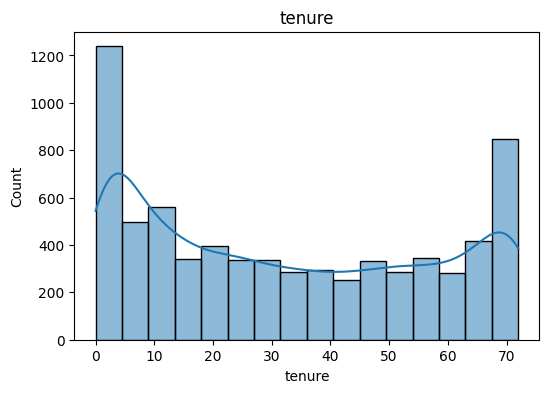

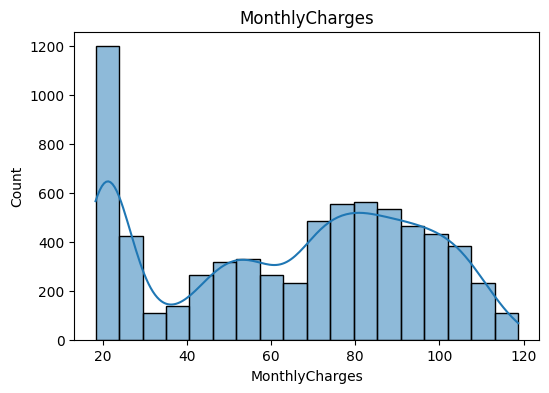

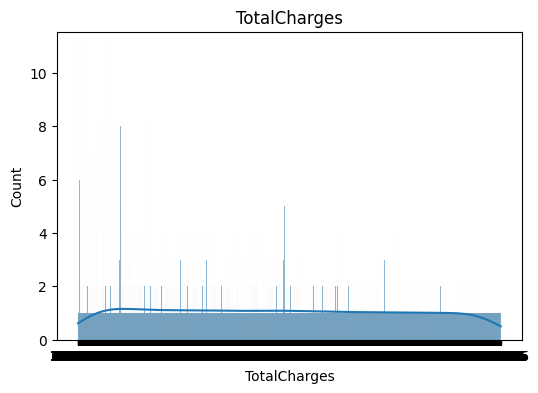

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(dataset[col], kde=True)
    plt.title(col)
    plt.show()

In [15]:
print(dataset["TotalCharges"].dtype)

object


In [16]:
dataset["TotalCharges"].describe()

count     7043
unique    6531
top           
freq        11
Name: TotalCharges, dtype: object

In [17]:
for col in ["tenure", "MonthlyCharges"]:
    print(f"\n{col}")
    print("Skewness:", dataset[col].skew())


tenure
Skewness: 0.2395397495619829

MonthlyCharges
Skewness: -0.22052443394398033


In [18]:
dataset["TotalCharges"].sample(10)

202      7405.5
3530       1108
4722     4224.7
6386     6093.3
1025    6668.35
626      1968.1
2365     1743.9
1383      49.95
4223      220.4
4746     162.45
Name: TotalCharges, dtype: object

In [19]:
(dataset["TotalCharges"] == " ").sum()

np.int64(11)

In [20]:
dataset["TotalCharges"] = pd.to_numeric(
    dataset["TotalCharges"],
    errors="coerce"
)

In [21]:
dataset["TotalCharges"].dtype

dtype('float64')

In [22]:
dataset["TotalCharges"].isnull().sum()

np.int64(11)

In [23]:
dataset.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

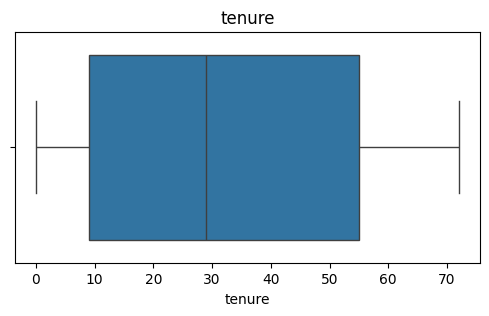

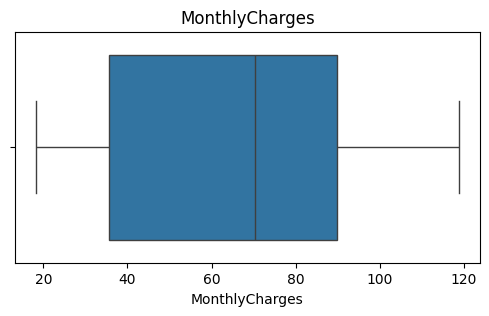

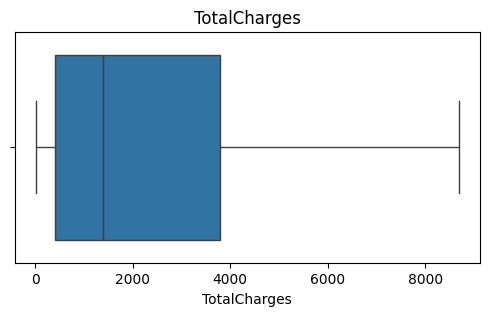

In [24]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=dataset[col])
    plt.title(col)
    plt.show()

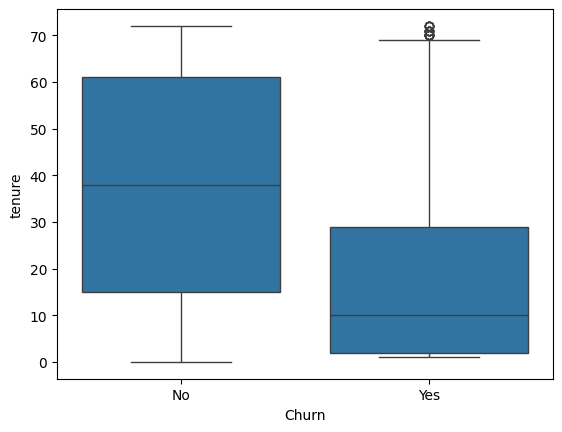

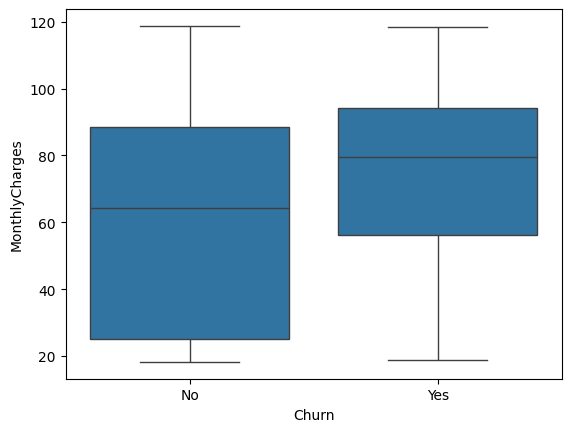

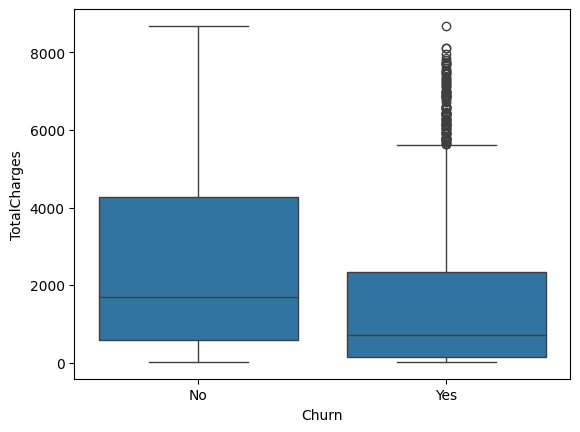

In [25]:
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    sns.boxplot(
        x="Churn",
        y=col,
        data=dataset
    )
    plt.show()

# 8. Correlation Analysis

A correlation matrix was generated using the numerical features.

| Feature Pair | Correlation |
|--------------|------------|
| tenure ↔ MonthlyCharges | 0.25 |
| tenure ↔ TotalCharges | 0.83 |
| MonthlyCharges ↔ TotalCharges | 0.65 |

---

## Observations

### Tenure and TotalCharges

Correlation: **0.83**

- Strong positive relationship.
- Customers with longer tenure naturally accumulate larger total charges.

### MonthlyCharges and TotalCharges

Correlation: **0.65**

- Moderate positive relationship.
- Higher monthly bills contribute to larger accumulated charges.

### Tenure and MonthlyCharges

Correlation: **0.25**

- Weak positive relationship.
- Subscription duration appears largely independent of monthly pricing.

---

## Business Interpretation

TotalCharges can be viewed as a function of both:

- tenure
- MonthlyCharges

This explains the strong correlation observed between these variables.

---

# 9. Key Findings from Numerical EDA

### Data Quality Findings

- Hidden missing values were discovered in `TotalCharges`.
- The column required datatype conversion before analysis.

### Target Variable Findings

- Customer churn is moderately imbalanced.
- Approximately 26.5% of customers have churned.

### Numerical Feature Findings

- tenure exhibits strong separation between churned and retained customers.
- MonthlyCharges is higher among churned customers.
- TotalCharges is lower among churned customers.

### Correlation Findings

- Strong correlation exists between tenure and TotalCharges.
- TotalCharges likely captures information related to customer tenure.

### Outlier Findings

- No major outlier concerns were identified.
- Extreme values appear valid and business-consistent.

---

# Conclusion

The numerical analysis suggests that customer tenure is one of the strongest indicators of churn behavior.

Customers who leave the company tend to:

- Have shorter tenure
- Pay higher monthly charges
- Accumulate lower total charges

Additionally, a strong relationship exists between tenure and total accumulated charges, indicating potential overlap in the information captured by these features.


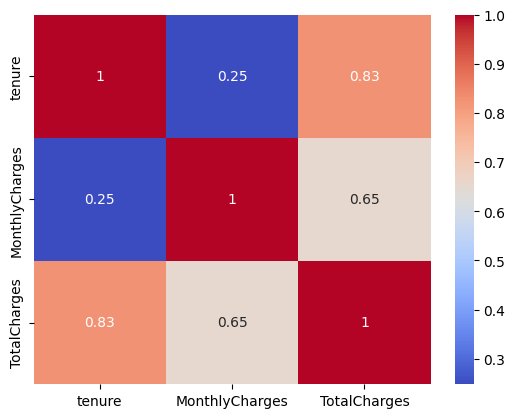

In [26]:
num_cols = ["tenure","MonthlyCharges","TotalCharges"]

sns.heatmap(
    dataset[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

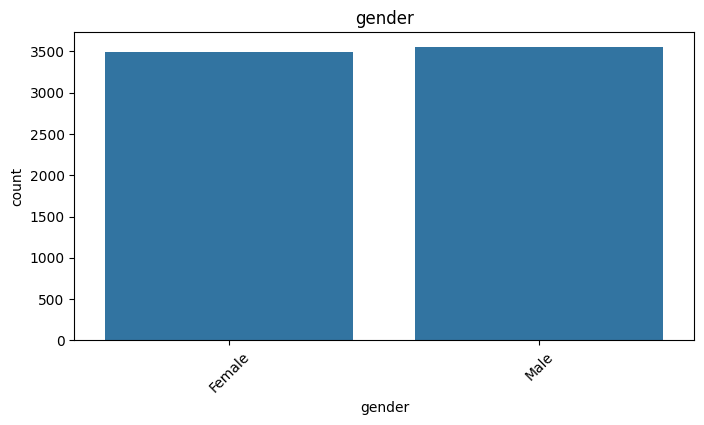

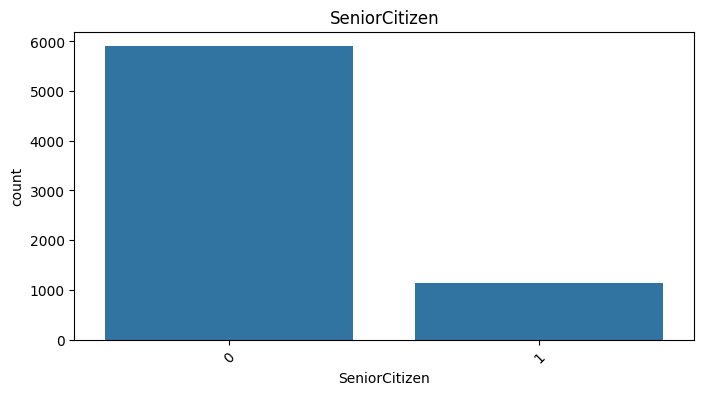

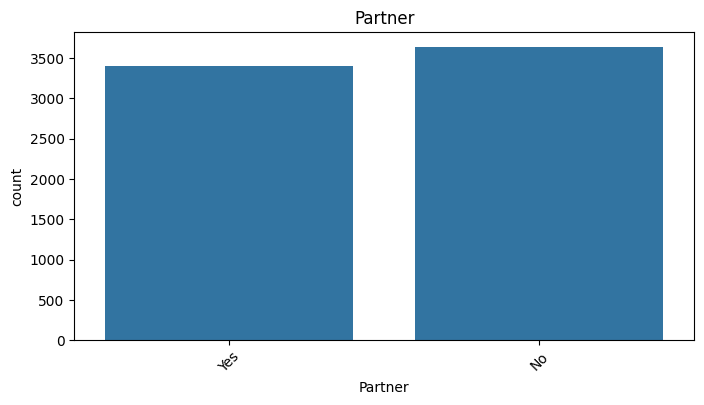

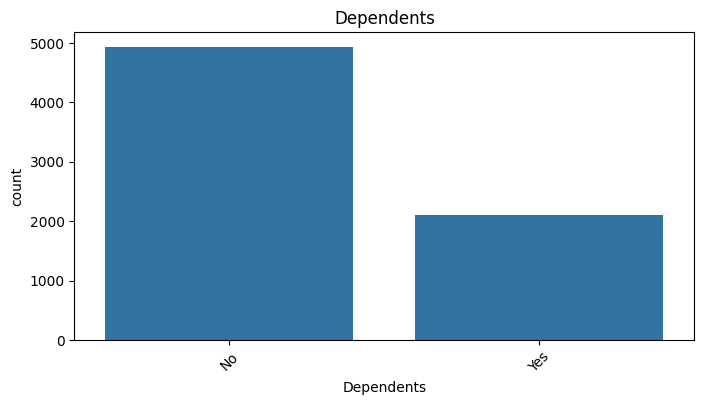

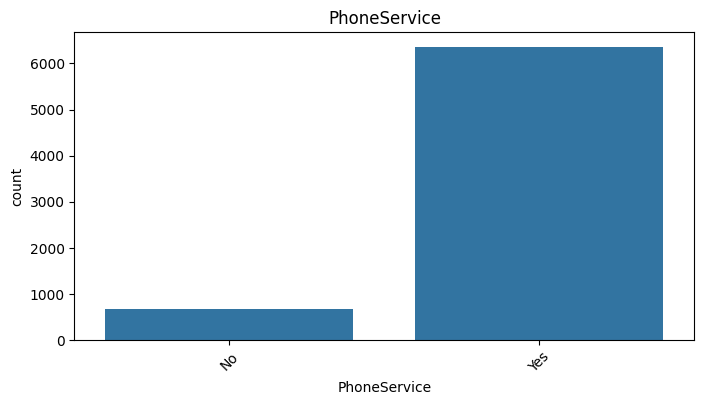

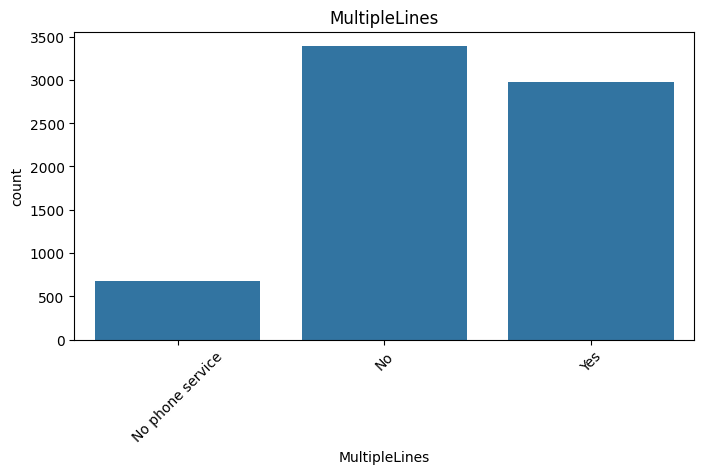

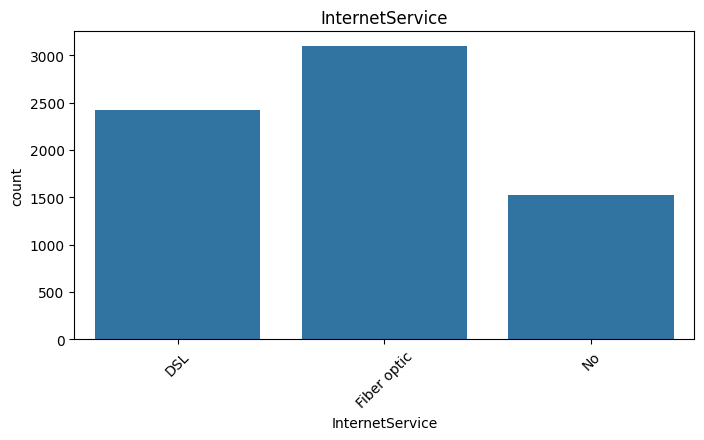

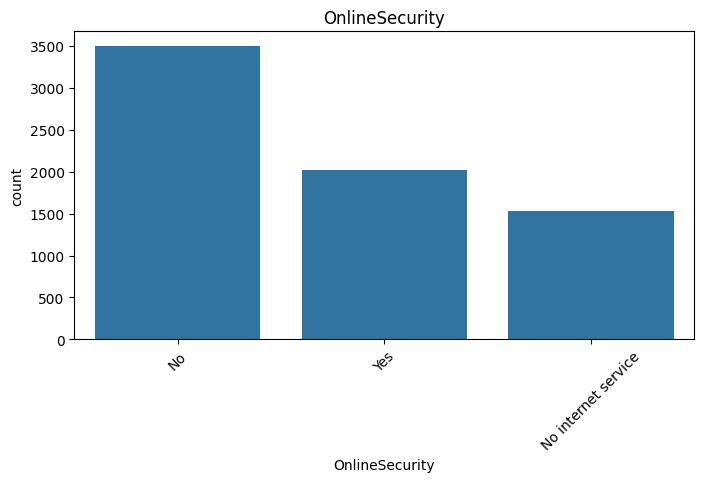

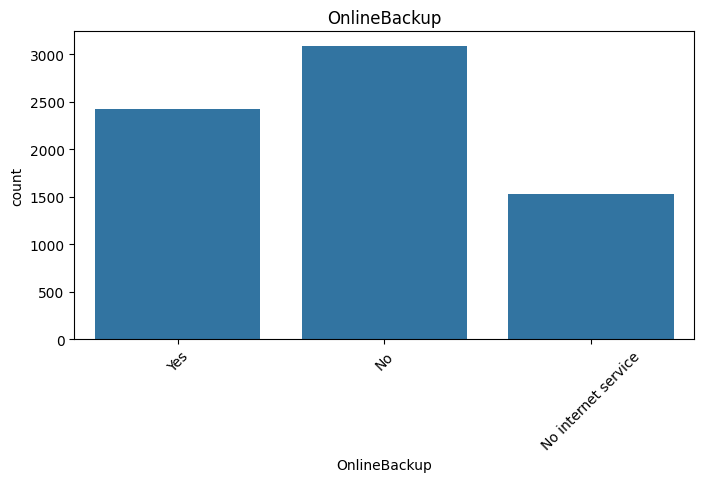

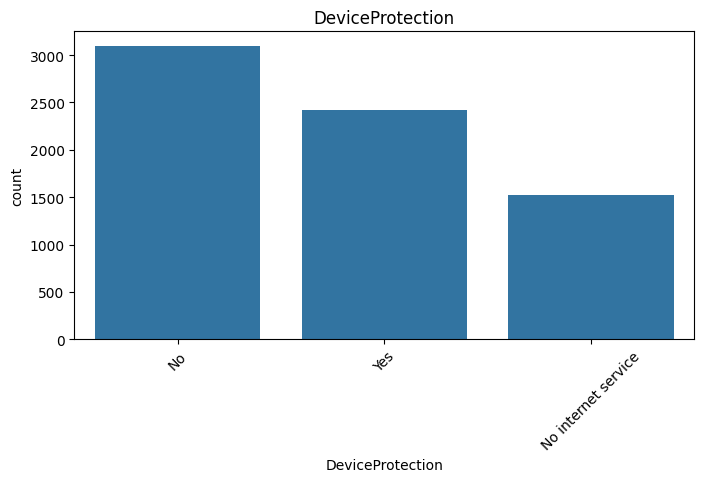

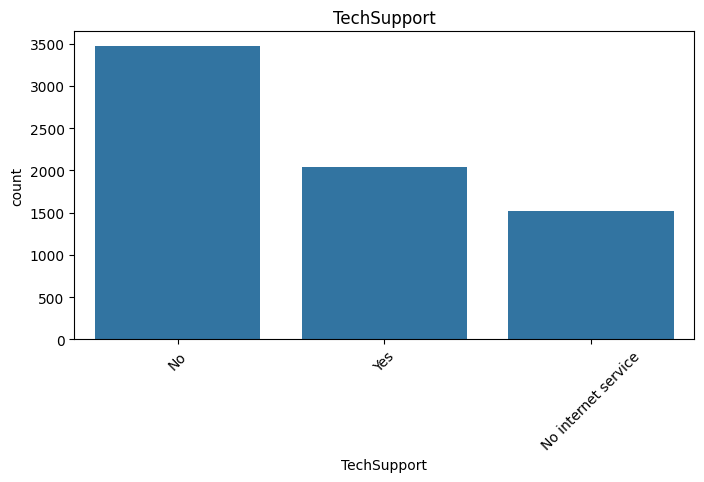

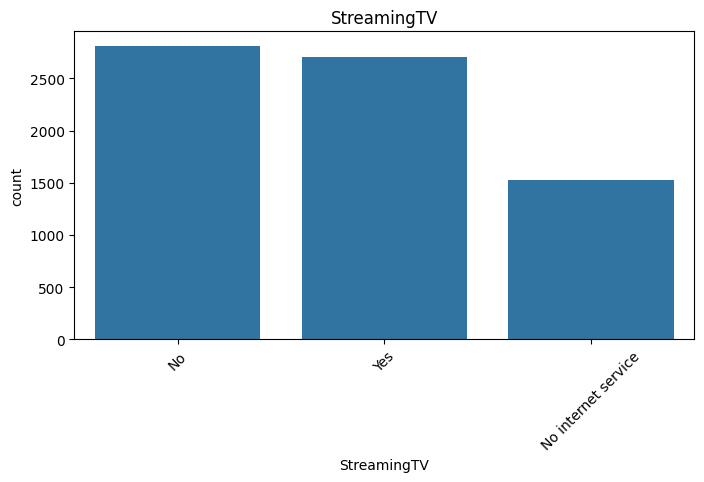

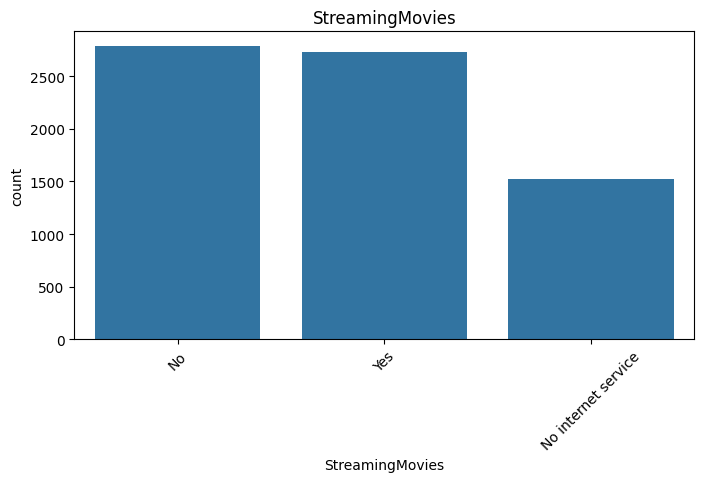

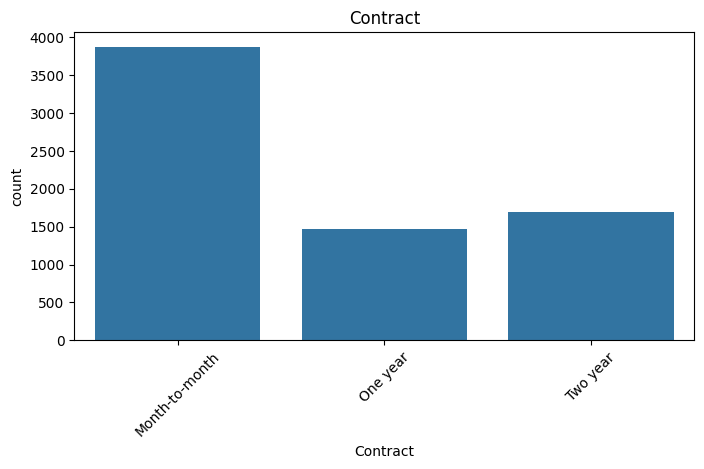

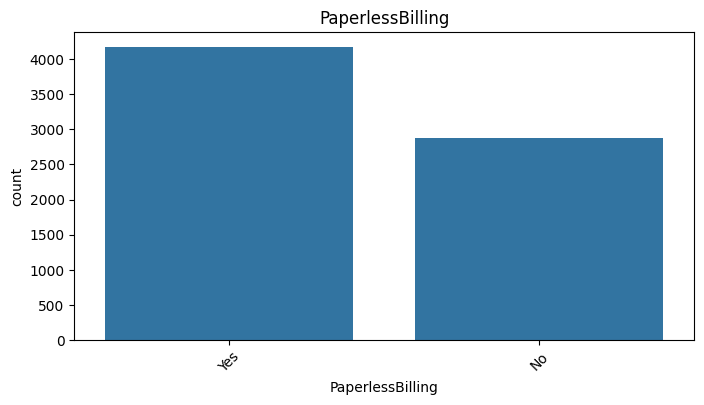

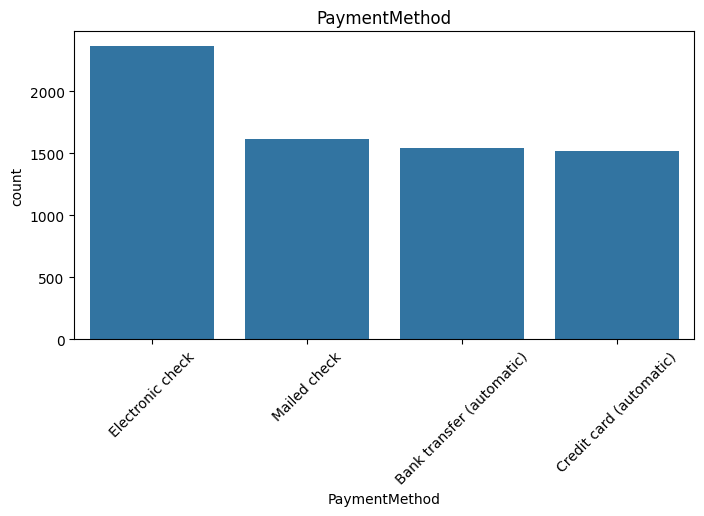

In [27]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=dataset, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

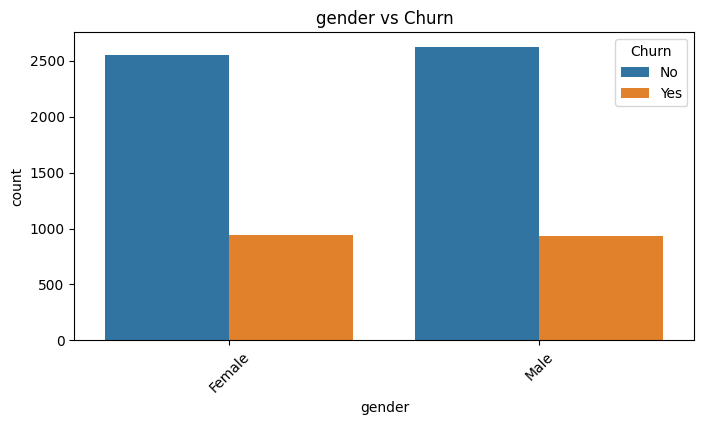

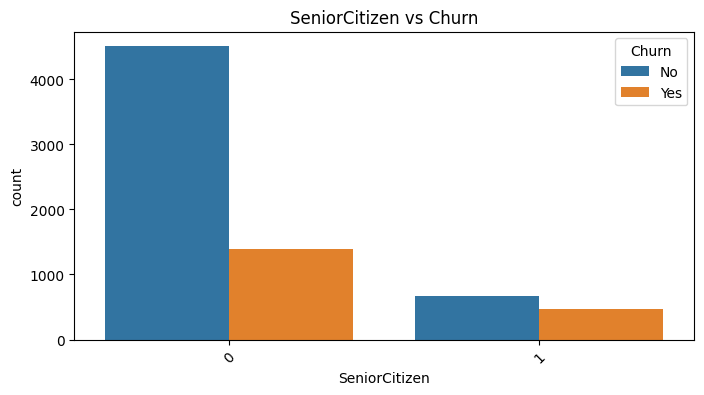

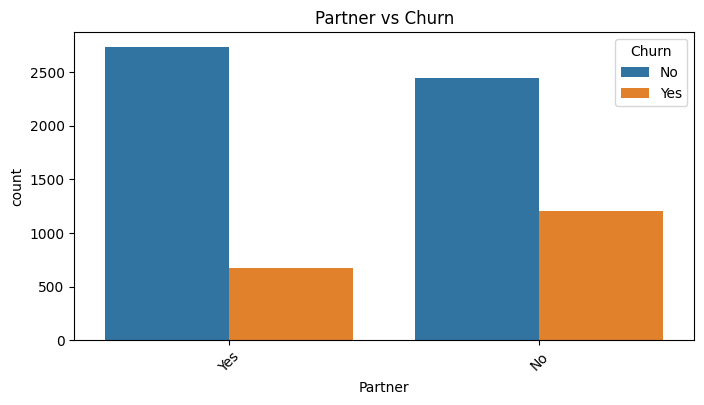

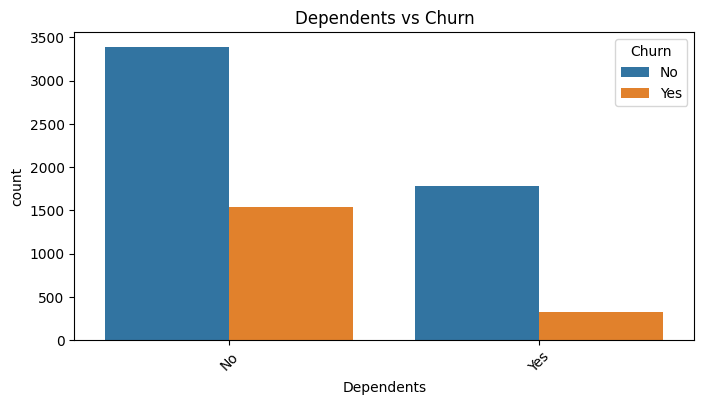

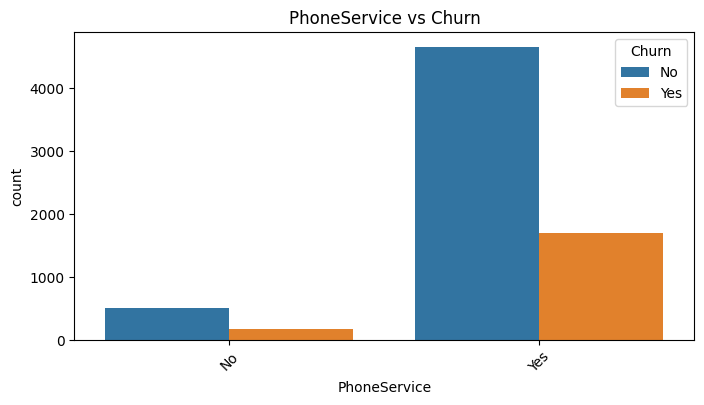

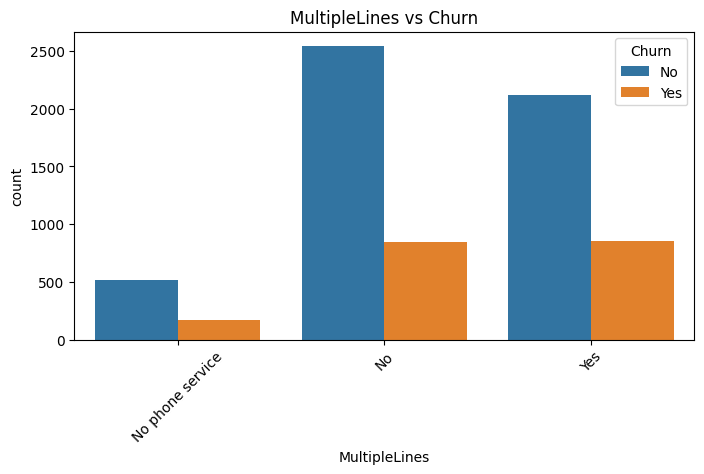

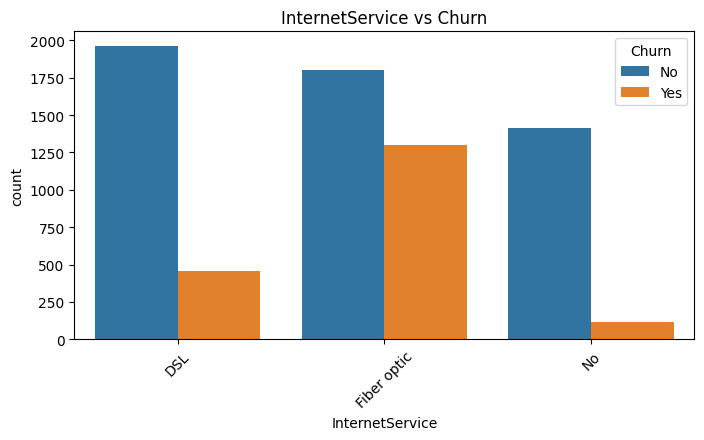

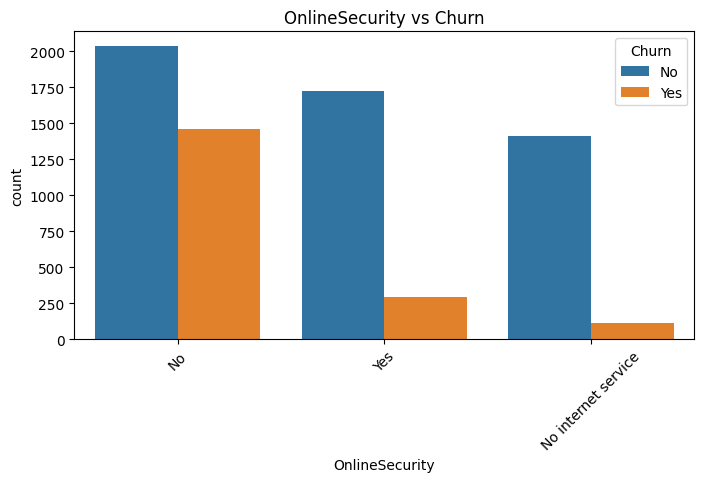

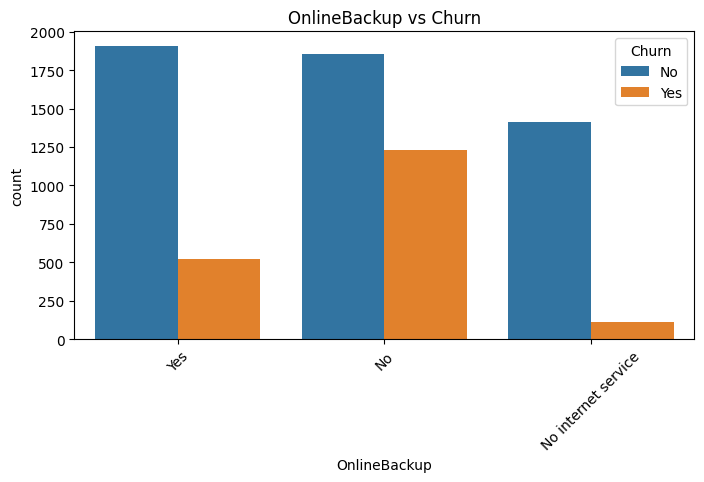

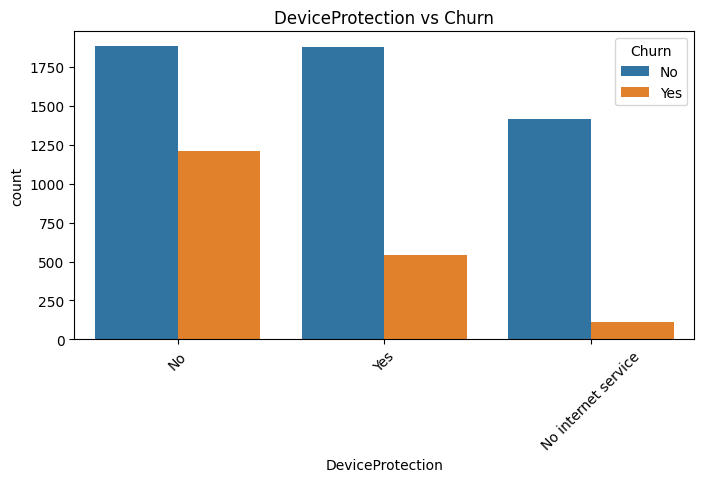

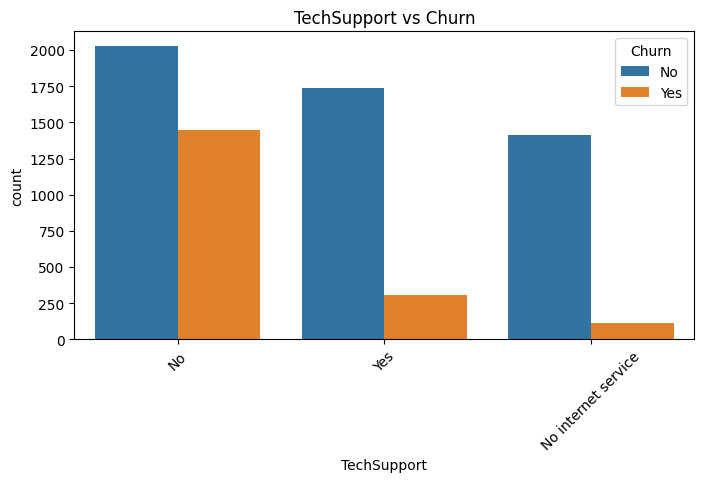

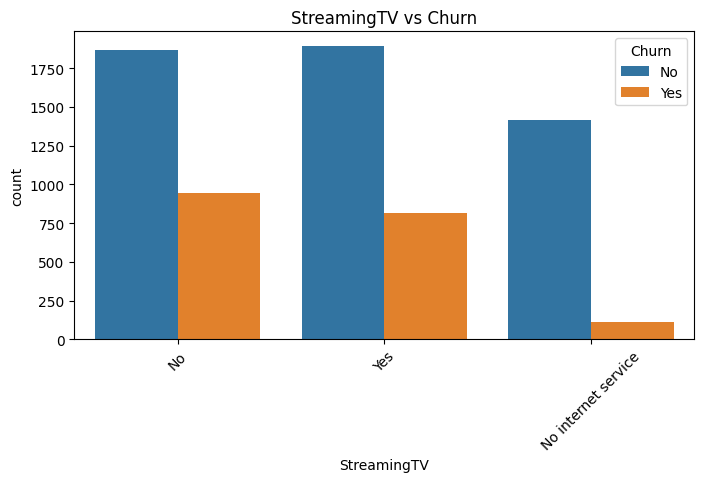

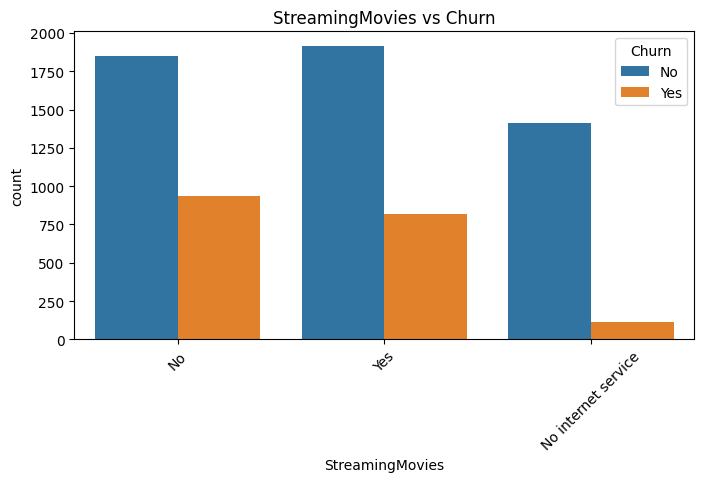

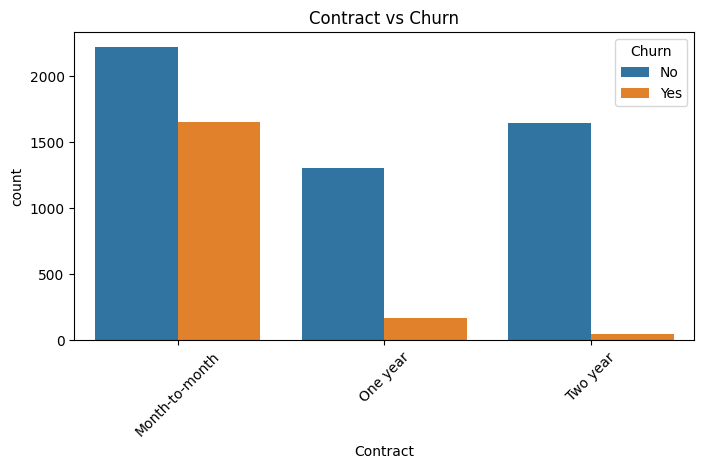

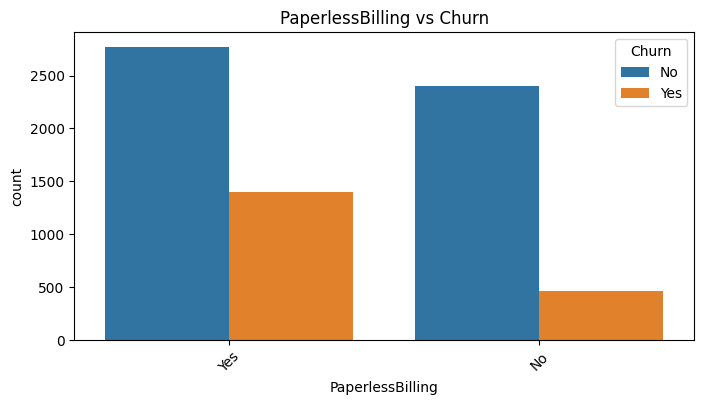

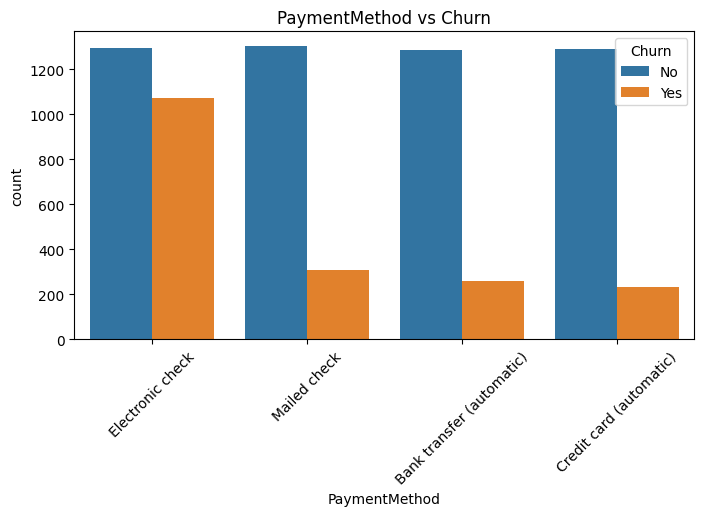

In [28]:
for col in cat_cols:
    plt.figure(figsize=(8,4))

    sns.countplot(
        data=dataset,
        x=col,
        hue="Churn"
    )

    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

# 10. Categorical Feature Analysis

The dataset contains multiple categorical variables describing customer demographics, subscribed services, billing preferences, and contract information.

Categorical EDA was performed to understand the distribution of categories and their relationship with customer churn.

---

# 10.1 Gender

| Gender | Churn Rate (%) |
|----------|----------|
| Female | 26.92 |
| Male | 26.16 |

### Observations

- Churn rates are nearly identical for both genders.
- No significant difference is observed between male and female customers.

### Interpretation

Gender does not appear to have a strong influence on customer churn.

### Predictive Importance

Low

---

# 10.2 Senior Citizen

| Senior Citizen | Churn Rate (%) |
|----------------|----------|
| No | 23.61 |
| Yes | 41.68 |

### Observations

- Senior citizens exhibit a substantially higher churn rate.
- The churn rate among senior citizens is nearly twice that of non-senior customers.

### Interpretation

Senior citizens appear more likely to discontinue services.

### Predictive Importance

Moderate to High

---

# 10.3 Partner

| Partner | Churn Rate (%) |
|----------|----------|
| No | 32.96 |
| Yes | 19.66 |

### Observations

- Customers without partners churn more frequently.
- Having a partner is associated with lower churn.

### Interpretation

Customers with partners may have more stable service requirements and longer retention periods.

### Predictive Importance

High

---

# 10.4 Dependents

| Dependents | Churn Rate (%) |
|------------|----------|
| No | 31.28 |
| Yes | 15.45 |

### Observations

- Customers without dependents churn at approximately twice the rate of customers with dependents.

### Interpretation

Customers with dependents may rely more heavily on telecommunication services and therefore exhibit stronger retention.

### Predictive Importance

High

---

# 10.5 Phone Service

| Phone Service | Churn Rate (%) |
|---------------|----------|
| No | 24.93 |
| Yes | 26.71 |

### Observations

- Churn rates are nearly identical across categories.

### Interpretation

Phone service alone does not appear to meaningfully influence churn behavior.

### Predictive Importance

Low

---

# 10.6 Multiple Lines

| Multiple Lines | Churn Rate (%) |
|----------------|----------|
| No | 25.04 |
| No phone service | 24.93 |
| Yes | 28.61 |

### Observations

- Churn rates are relatively similar across categories.

### Interpretation

The number of phone lines appears to have limited influence on customer churn.

### Predictive Importance

Low

---

# 10.7 Internet Service

| Internet Service | Churn Rate (%) |
|------------------|----------|
| DSL | 18.96 |
| Fiber optic | 41.89 |
| No internet service | 7.40 |

### Observations

- Fiber optic customers exhibit the highest churn rate.
- Customers without internet service show the lowest churn rate.

### Interpretation

Internet service type is strongly associated with churn behavior.

### Predictive Importance

Very High

---

# 10.8 Online Security

| Online Security | Churn Rate (%) |
|-----------------|----------|
| No | 41.77 |
| Yes | 14.61 |
| No internet service | 7.40 |

### Observations

- Customers without online security churn nearly three times more frequently than customers with online security.

### Interpretation

Online security appears to be strongly associated with customer retention.

### Predictive Importance

Very High

---

# 10.9 Online Backup

| Online Backup | Churn Rate (%) |
|---------------|----------|
| No | 39.93 |
| Yes | 21.53 |
| No internet service | 7.40 |

### Observations

- Customers without online backup exhibit significantly higher churn.

### Interpretation

Backup services may increase customer engagement and reduce churn risk.

### Predictive Importance

High

---

# 10.10 Device Protection

| Device Protection | Churn Rate (%) |
|-------------------|----------|
| No | 39.13 |
| Yes | 22.50 |
| No internet service | 7.40 |

### Observations

- Customers lacking device protection churn substantially more often.

### Interpretation

Additional protection services appear to improve customer retention.

### Predictive Importance

High

---

# 10.11 Tech Support

| Tech Support | Churn Rate (%) |
|--------------|----------|
| No | 41.64 |
| Yes | 15.17 |
| No internet service | 7.40 |

### Observations

- Customers without technical support churn nearly three times more frequently.

### Interpretation

Access to technical support appears strongly associated with customer satisfaction and retention.

### Predictive Importance

Very High

---

# 10.12 Streaming TV

| Streaming TV | Churn Rate (%) |
|--------------|----------|
| No | 33.52 |
| Yes | 30.07 |
| No internet service | 7.40 |

### Observations

- Churn differences are relatively small.

### Interpretation

Streaming TV services do not appear to substantially influence churn.

### Predictive Importance

Low to Moderate

---

# 10.13 Streaming Movies

| Streaming Movies | Churn Rate (%) |
|------------------|----------|
| No | 33.68 |
| Yes | 29.94 |
| No internet service | 7.40 |

### Observations

- Churn rates are similar across categories.

### Interpretation

Streaming movie subscriptions show limited predictive value.

### Predictive Importance

Low to Moderate

---

# 10.14 Contract Type

| Contract Type | Churn Rate (%) |
|---------------|----------|
| Month-to-month | 42.71 |
| One year | 11.27 |
| Two year | 2.83 |

### Observations

- Month-to-month customers exhibit the highest churn rate.
- Two-year contract customers show extremely low churn.

### Interpretation

Contract duration is one of the strongest indicators of customer churn.

Long-term contracts appear highly effective in customer retention.

### Predictive Importance

Extremely High

---

# 10.15 Paperless Billing

| Paperless Billing | Churn Rate (%) |
|-------------------|----------|
| No | 16.33 |
| Yes | 33.57 |

### Observations

- Customers using paperless billing churn at approximately twice the rate of customers using traditional billing.

### Interpretation

Billing preferences appear associated with churn behavior.

### Predictive Importance

Moderate to High

---

# 10.16 Payment Method

| Payment Method | Churn Rate (%) |
|----------------|----------|
| Bank transfer (automatic) | 16.71 |
| Credit card (automatic) | 15.24 |
| Electronic check | 45.29 |
| Mailed check | 19.11 |

### Observations

- Customers using electronic checks exhibit substantially higher churn rates.
- Automatic payment methods show the lowest churn rates.

### Interpretation

Payment method is strongly associated with customer retention.

Automatic payment systems appear linked to lower churn behavior.

### Predictive Importance

Very High

---

# 11. Key Findings from Categorical EDA

### Strongest Predictors Identified

The following features exhibited the strongest relationship with churn:

1. Contract
2. InternetService
3. OnlineSecurity
4. TechSupport
5. PaymentMethod
6. Partner
7. Dependents
8. SeniorCitizen

---

### Service-Based Insights

Customers without the following services exhibited significantly higher churn rates:

- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport

This suggests that customers using additional service offerings tend to be more retained.

---

### Contract-Based Insights

Contract type emerged as the strongest categorical predictor.

Customers with longer-term contracts demonstrated dramatically lower churn rates compared to month-to-month customers.

---

### Billing and Payment Insights

- Electronic check users exhibited the highest churn rates.
- Automatic payment methods showed the lowest churn rates.
- Paperless billing customers churned more frequently than traditional billing customers.

---

### Demographic Insights

- Senior citizens showed higher churn rates.
- Customers without partners or dependents were more likely to churn.
- Gender exhibited negligible impact on churn behavior.

---

# Conclusion

Categorical feature analysis revealed several strong relationships with customer churn.

Contract type, internet service type, online security, technical support, and payment method demonstrated the strongest associations with customer retention.

These findings suggest that both service-related features and billing-related features play a major role in determining whether a customer is likely to churn.

Combined with the numerical analysis, the dataset contains multiple highly informative predictors that are expected to contribute significantly during model development.

In [29]:
for col in cat_cols:
    print(f"\n{'='*60}")
    print(col)
    print('='*60)

    display(
        pd.crosstab(
            dataset[col],
            dataset["Churn"],
            normalize="index"
        ).mul(100).round(2)
    )


gender


Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16



SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68



Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83



PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57



PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [30]:
dataset = dataset.drop("customerID", axis=1)

In [31]:
dataset.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Data Splitting

Performed before preprocessing to avoid data leakage.

```python
Train      : 70%
Validation : 15%
Test       : 15%
```

Using:

```python
train_test_split(..., stratify=y)
```

to preserve class distribution.

## Final Shapes

```python
X_train : (4929, 19)
X_val   : (1057, 19)
X_test  : (1057, 19)

y_train : (4929,)
y_val   : (1057,)
y_test  : (1057,)
```

---

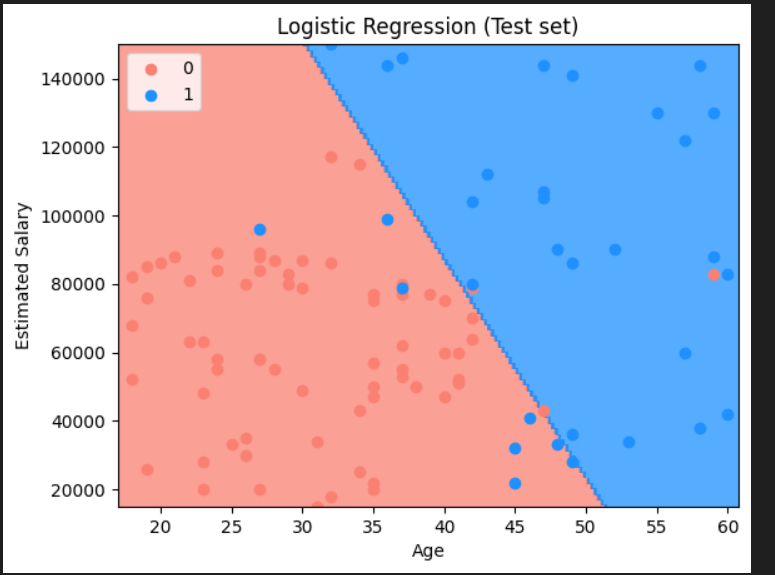
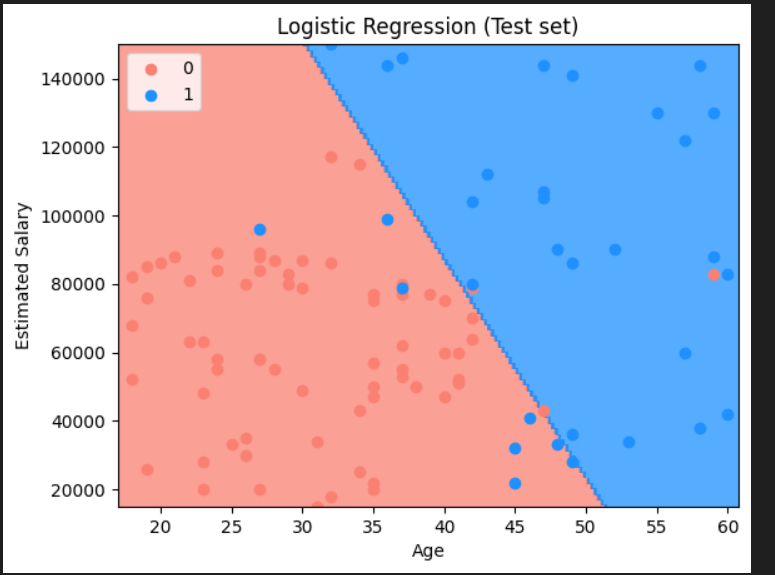

In [32]:
X = dataset.drop("Churn", axis=1)
y = dataset["Churn"]

In [33]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    stratify=y_train_val,
    random_state=42
)

In [34]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4929, 19)
X_val shape: (1057, 19)
X_test shape: (1057, 19)

y_train shape: (4929,)
y_val shape: (1057,)
y_test shape: (1057,)


# Missing Value Handling

## Hidden Missing Values

Column:

```python
TotalCharges
```

Initially appeared complete because it was stored as an object column.

After:

```python
pd.to_numeric(errors="coerce")
```

11 missing values were discovered.

---

## Imputation

Performed after train-validation-test split.

Method:

```python
SimpleImputer(strategy="median")
```

Only fitted on:

```python
X_train
```

Then applied to:

```python
X_val
X_test
```

to prevent leakage.

---

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[["TotalCharges"]])
X_train["TotalCharges"] = imputer.transform(X_train[["TotalCharges"]])
X_val["TotalCharges"] = imputer.transform(X_val[["TotalCharges"]])
X_test["TotalCharges"] = imputer.transform(X_test[["TotalCharges"]])

In [36]:
print(X_train["TotalCharges"].isna().sum())
print(X_val["TotalCharges"].isna().sum())
print(X_test["TotalCharges"].isna().sum())

0
0
0


# Encoding

## Binary Encoding

Columns:

```python
gender
Partner
Dependents
PhoneService
PaperlessBilling
```

Used:

```python
OneHotEncoder(drop="if_binary")
```

---

## One-Hot Encoding

Columns:

```python
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod
```

Used:

```python
OneHotEncoder(handle_unknown="ignore")
```

Reason:

These are nominal categories with no meaningful numerical ordering.

---

## Ordinal Encoding

Not used.

Reason:

No categorical feature had a reliable ordinal relationship worth imposing.

---

In [42]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

ohe_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
]

In [52]:
encoder = ColumnTransformer(
    transformers=[
        ("binary", OneHotEncoder(drop="if_binary"), binary_cols),
        ("ohe", OneHotEncoder(handle_unknown="ignore"), ohe_cols)
    ],
    remainder="passthrough"
)

In [54]:
encoder.fit(X_train)
X_train_encoded = encoder.transform(X_train)
X_val_encoded = encoder.transform(X_val)
X_test_encoded = encoder.transform(X_test)

In [55]:
print(X_train_encoded.shape)
print(X_val_encoded.shape)
print(X_test_encoded.shape)

(4929, 40)
(1057, 40)
(1057, 40)


In [56]:
feature_names = encoder.get_feature_names_out()

print(len(feature_names))
print(feature_names)

40
['binary__gender_Male' 'binary__Partner_Yes' 'binary__Dependents_Yes'
 'binary__PhoneService_Yes' 'binary__PaperlessBilling_Yes'
 'ohe__MultipleLines_No' 'ohe__MultipleLines_No phone service'
 'ohe__MultipleLines_Yes' 'ohe__InternetService_DSL'
 'ohe__InternetService_Fiber optic' 'ohe__InternetService_No'
 'ohe__OnlineSecurity_No' 'ohe__OnlineSecurity_No internet service'
 'ohe__OnlineSecurity_Yes' 'ohe__OnlineBackup_No'
 'ohe__OnlineBackup_No internet service' 'ohe__OnlineBackup_Yes'
 'ohe__DeviceProtection_No' 'ohe__DeviceProtection_No internet service'
 'ohe__DeviceProtection_Yes' 'ohe__TechSupport_No'
 'ohe__TechSupport_No internet service' 'ohe__TechSupport_Yes'
 'ohe__StreamingTV_No' 'ohe__StreamingTV_No internet service'
 'ohe__StreamingTV_Yes' 'ohe__StreamingMovies_No'
 'ohe__StreamingMovies_No internet service' 'ohe__StreamingMovies_Yes'
 'ohe__Contract_Month-to-month' 'ohe__Contract_One year'
 'ohe__Contract_Two year' 'ohe__PaymentMethod_Bank transfer (automatic)'
 'ohe__P

In [48]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_val   = y_val.map({"No": 0, "Yes": 1})
y_test  = y_test.map({"No": 0, "Yes": 1})

# Scaling

Numerical Features:

```python
tenure
MonthlyCharges
TotalCharges
```

Used:

```python
StandardScaler()
```

Fit only on:

```python
X_train
```

Applied to:

```python
X_val
X_test
```

to avoid data leakage.

---


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[["tenure", "MonthlyCharges", "TotalCharges"]])
X_train[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.transform(
    X_train[["tenure", "MonthlyCharges", "TotalCharges"]]
)
X_val[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.transform(
    X_val[["tenure", "MonthlyCharges", "TotalCharges"]]
)
X_test[["tenure", "MonthlyCharges", "TotalCharges"]] = scaler.transform(
    X_test[["tenure", "MonthlyCharges", "TotalCharges"]]
)

# Baseline Logistic Regression

Model:

```python
LogisticRegression(
    random_state=42,
    max_iter=1000
)
```

## Validation Results

```text
Accuracy : 0.7947
Precision: 0.6416
Recall   : 0.5160
F1 Score : 0.5720
ROC-AUC  : 0.8297
```

Confusion Matrix:

```text
[[695  81]
 [136 145]]
```

---


In [59]:
from sklearn.linear_model import LogisticRegression

baseline_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_lr.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [60]:
y_pred = baseline_lr.predict(X_val_encoded)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.metrics import roc_auc_score

print("Accuracy :", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall   :", recall_score(y_val, y_pred))
print("F1 Score :", f1_score(y_val, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_val, y_pred))
y_prob = baseline_lr.predict_proba(X_val_encoded)[:, 1]
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

Accuracy : 0.7947019867549668
Precision: 0.6415929203539823
Recall   : 0.5160142348754448
F1 Score : 0.571992110453649

Confusion Matrix
[[695  81]
 [136 145]]
ROC-AUC: 0.8297363979895074


In [63]:
results = []

def evaluate_model(model, model_name):
    
    model.fit(X_train_encoded, y_train)

    y_pred = model.predict(X_val_encoded)
    y_prob = model.predict_proba(X_val_encoded)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)

    results.append([
        model_name,
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    print(f"\n{model_name}")
    print("-"*50)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("ROC-AUC  :", auc)
    print("\nConfusion Matrix")
    print(confusion_matrix(y_val, y_pred))

# Regularized Logistic Regression

## L1 Regularization

Tested:

```python
C = [0.01, 0.1, 1, 10]
```

Best Result:

```text
L1 (C=1)

F1 Score : 0.5731
ROC-AUC  : 0.8297
```

---

## L2 Regularization

Tested:

```python
C = [0.01, 0.1, 1, 10]
```

Best Result:

```text
L2 (C=1)

F1 Score : 0.5720
ROC-AUC  : 0.8297
```

---

In [64]:
from sklearn.linear_model import LogisticRegression

for c in [0.01, 0.1, 1, 10]:
    
    l1_lr = LogisticRegression(
        penalty="l1",
        C=c,
        solver="liblinear",
        random_state=42,
        max_iter=1000
    )

    evaluate_model(l1_lr, f"L1 Logistic (C={c})")


L1 Logistic (C=0.01)
--------------------------------------------------
Accuracy : 0.7861873226111636
Precision: 0.6646706586826348
Recall   : 0.39501779359430605
F1 Score : 0.4955357142857143
ROC-AUC  : 0.8047290604248449

Confusion Matrix
[[720  56]
 [170 111]]

L1 Logistic (C=0.1)
--------------------------------------------------
Accuracy : 0.7947019867549668
Precision: 0.6441441441441441
Recall   : 0.5088967971530249
F1 Score : 0.5685884691848907
ROC-AUC  : 0.8270879957442124

Confusion Matrix
[[697  79]
 [138 143]]

L1 Logistic (C=1)
--------------------------------------------------
Accuracy : 0.7956480605487228
Precision: 0.6444444444444445
Recall   : 0.5160142348754448
F1 Score : 0.5731225296442688
ROC-AUC  : 0.8296767802766263

Confusion Matrix
[[696  80]
 [136 145]]

L1 Logistic (C=10)
--------------------------------------------------
Accuracy : 0.793755912961211
Precision: 0.6387665198237885
Recall   : 0.5160142348754448
F1 Score : 0.5708661417322834
ROC-AUC  : 0.82992442

In [65]:
for c in [0.01, 0.1, 1, 10]:
    
    l2_lr = LogisticRegression(
        penalty="l2",
        C=c,
        random_state=42,
        max_iter=1000
    )

    evaluate_model(l2_lr, f"L2 Logistic (C={c})")


L2 Logistic (C=0.01)
--------------------------------------------------
Accuracy : 0.7984862819299905
Precision: 0.6634615384615384
Recall   : 0.49110320284697506
F1 Score : 0.5644171779141104
ROC-AUC  : 0.8262327108632644

Confusion Matrix
[[706  70]
 [143 138]]

L2 Logistic (C=0.1)
--------------------------------------------------
Accuracy : 0.7947019867549668
Precision: 0.6428571428571429
Recall   : 0.5124555160142349
F1 Score : 0.5702970297029702
ROC-AUC  : 0.8287595846938401

Confusion Matrix
[[696  80]
 [137 144]]

L2 Logistic (C=1)
--------------------------------------------------
Accuracy : 0.7947019867549668
Precision: 0.6415929203539823
Recall   : 0.5160142348754448
F1 Score : 0.571992110453649
ROC-AUC  : 0.8297363979895074

Confusion Matrix
[[695  81]
 [136 145]]

L2 Logistic (C=10)
--------------------------------------------------
Accuracy : 0.7918637653736992
Precision: 0.6331877729257642
Recall   : 0.5160142348754448
F1 Score : 0.5686274509803921
ROC-AUC  : 0.82996569

# SGD Classifier

Model:

```python
SGDClassifier(loss="log_loss")
```

Tested:

```python
alpha = [
    0.0001,
    0.001,
    0.01,
    0.1
]
```

Best Result:

```text
alpha = 0.01

Accuracy : 0.7900
Precision: 0.6224
Recall   : 0.5338
F1 Score : 0.5747
ROC-AUC  : 0.8268
```

---

In [66]:
from sklearn.linear_model import SGDClassifier

for alpha in [0.0001, 0.001, 0.01, 0.1]:

    sgd = SGDClassifier(
        loss="log_loss",
        alpha=alpha,
        random_state=42
    )

    sgd.fit(X_train_encoded, y_train)

    y_pred = sgd.predict(X_val_encoded)

    try:
        y_prob = sgd.predict_proba(X_val_encoded)[:,1]
        auc = roc_auc_score(y_val, y_prob)
    except:
        auc = None

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    results.append([
        f"SGD(alpha={alpha})",
        acc,
        prec,
        rec,
        f1,
        auc
    ])

    print(f"\nSGD(alpha={alpha})")
    print("-"*50)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)
    print("ROC-AUC  :", auc)


SGD(alpha=0.0001)
--------------------------------------------------
Accuracy : 0.7956480605487228
Precision: 0.6457399103139013
Recall   : 0.5124555160142349
F1 Score : 0.5714285714285714
ROC-AUC  : 0.8265812451847232

SGD(alpha=0.001)
--------------------------------------------------
Accuracy : 0.7975402081362346
Precision: 0.6543778801843319
Recall   : 0.505338078291815
F1 Score : 0.570281124497992
ROC-AUC  : 0.8273333455626078

SGD(alpha=0.01)
--------------------------------------------------
Accuracy : 0.7899716177861873
Precision: 0.6224066390041494
Recall   : 0.5338078291814946
F1 Score : 0.5747126436781609
ROC-AUC  : 0.8268288879920755

SGD(alpha=0.1)
--------------------------------------------------
Accuracy : 0.7871333964049196
Precision: 0.6971830985915493
Recall   : 0.35231316725978645
F1 Score : 0.46808510638297873
ROC-AUC  : 0.8234123344461973


# Hyperparameter Tuning

Used:

```python
RandomizedSearchCV
```

Scoring Metric:

```python
F1
```

Cross Validation:

```python
cv = 5
```

---

## Tuned L1 Logistic Regression

Best Parameter:

```python
C = 15.56
```

Cross-Validation F1:

```text
0.6063
```

Validation Performance:

```text
F1 Score : 0.5686
ROC-AUC  : 0.8300
```

Observation:

Although CV score improved, validation F1 decreased slightly.

Important lesson:

```text
Best CV score ≠ Best Validation score
```

---

## Tuned SGD

Best Parameters:

```python
alpha ≈ 0.0095
penalty = elasticnet
loss = log_loss
```

Validation Performance:

```text
F1 Score : 0.5809
ROC-AUC  : 0.8268
```

Best validation model overall.

---

In [67]:
from sklearn.model_selection import RandomizedSearchCV

l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    random_state=42,
    max_iter=1000
)

param_dist = {
    "C": np.logspace(-3, 2, 100)
}

random_search_l1 = RandomizedSearchCV(
    estimator=l1_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_l1.fit(X_train_encoded, y_train)

RandomizedSearchCV(cv=5,
                   estimator=LogisticRegression(max_iter=1000, penalty='l1',
                                                random_state=42,
                                                solver='liblinear'),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-03, 1.12332403e-03, 1.26185688e-03, 1.41747416e-03,
       1.59228279e-03, 1.78864953e-03, 2.00923300e-03, 2.25701972e-03,
       2.53536449e-03, 2.84803587e-03, 3.19926714e-03, 3.59381366e-03,
       4....
       6.89261210e+00, 7.74263683e+00, 8.69749003e+00, 9.77009957e+00,
       1.09749877e+01, 1.23284674e+01, 1.38488637e+01, 1.55567614e+01,
       1.74752840e+01, 1.96304065e+01, 2.20513074e+01, 2.47707636e+01,
       2.78255940e+01, 3.12571585e+01, 3.51119173e+01, 3.94420606e+01,
       4.43062146e+01, 4.97702356e+01, 5.59081018e+01, 6.28029144e+01,
       7.05480231e+01, 7.92482898e+01, 8.90215085e+01, 1.00000000e+02])},
                   random_state=42, scoring='f1')

In [68]:
print(random_search_l1.best_params_)
print(random_search_l1.best_score_)

{'C': np.float64(15.556761439304722)}
0.606297455988374


In [69]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    loss="log_loss",
    random_state=42
)

param_dist = {
    "alpha": np.logspace(-5, 0, 100),
    "penalty": ["l1", "l2", "elasticnet"],
    "max_iter": [1000, 2000, 3000]
}

random_search_sgd = RandomizedSearchCV(
    estimator=sgd,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_sgd.fit(X_train_encoded, y_train)

RandomizedSearchCV(cv=5,
                   estimator=SGDClassifier(loss='log_loss', random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'alpha': array([1.00000000e-05, 1.12332403e-05, 1.26185688e-05, 1.41747416e-05,
       1.59228279e-05, 1.78864953e-05, 2.00923300e-05, 2.25701972e-05,
       2.53536449e-05, 2.84803587e-05, 3.19926714e-05, 3.59381366e-05,
       4.03701726e-05, 4.53487851e-05, 5.0...
       1.09749877e-01, 1.23284674e-01, 1.38488637e-01, 1.55567614e-01,
       1.74752840e-01, 1.96304065e-01, 2.20513074e-01, 2.47707636e-01,
       2.78255940e-01, 3.12571585e-01, 3.51119173e-01, 3.94420606e-01,
       4.43062146e-01, 4.97702356e-01, 5.59081018e-01, 6.28029144e-01,
       7.05480231e-01, 7.92482898e-01, 8.90215085e-01, 1.00000000e+00]),
                                        'max_iter': [1000, 2000, 3000],
                                        'penalty': ['l1', 'l2', 'elasticnet']},
                   random_state=42, scoring='f1')

In [70]:
print(random_search_sgd.best_params_)
print(random_search_sgd.best_score_)

{'penalty': 'elasticnet', 'max_iter': 1000, 'alpha': np.float64(0.009545484566618337)}
0.597112506045033


# Final Model Selection

Selected:

```python
SGDClassifier
```

Reason:

Highest validation F1 Score.

```text
Validation F1 = 0.5809
```

Primary project metric was F1.

---

# Final Test Evaluation

Using the tuned SGD model.

## Test Metrics

```text
Accuracy : 0.7975
Precision: 0.6279
Recall   : 0.5786
F1 Score : 0.6022
ROC-AUC  : 0.8462
```

Confusion Matrix:

```text
[[681  96]
 [118 162]]
```

---

# Interpretation

### Accuracy

```text
79.75%
```

Good overall classification performance.

---

### Precision

```text
62.79%
```

When the model predicts churn, it is correct about 63% of the time.

---

### Recall

```text
57.86%
```

The model successfully identifies approximately 58% of customers who actually churn.

---

### F1 Score

```text
0.6022
```

Best overall balance between Precision and Recall.

Primary project metric.

---

### ROC-AUC

```text
0.8462
```

Strong class-separation capability.

Interpretation:

A randomly chosen churned customer receives a higher churn probability than a randomly chosen non-churned customer approximately 85% of the time.

---

In [71]:
best_l1 = random_search_l1.best_estimator_

y_pred = best_l1.predict(X_val_encoded)
y_prob = best_l1.predict_proba(X_val_encoded)[:, 1]

print("F1:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

F1: 0.5686274509803921
ROC-AUC: 0.8299519389514619


In [77]:
best_sgd = random_search_sgd.best_estimator_

y_pred = best_sgd.predict(X_val_encoded)
y_prob = best_sgd.predict_proba(X_val_encoded)[:, 1]

print("F1:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

F1: 0.580896686159844
ROC-AUC: 0.8267922001687639


In [73]:
y_test_pred = best_sgd.predict(X_test_encoded)
y_test_prob = best_sgd.predict_proba(X_test_encoded)[:, 1]

In [76]:
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_test_pred))

Accuracy : 0.7975402081362346
Precision: 0.627906976744186
Recall   : 0.5785714285714286
F1 Score : 0.6022304832713755
ROC-AUC  : 0.8461642765214195

Confusion Matrix
[[681  96]
 [118 162]]


# Key Lessons Learned

1. Always split before preprocessing to prevent data leakage.

2. Fit preprocessing objects only on training data.

3. Accuracy alone is insufficient for imbalanced classification problems.

4. F1 Score provides a better balance between Precision and Recall.

5. Regularization does not always improve performance.

6. Cross-validation results must be verified on a validation set.

7. Different metrics can favor different models.

8. Hyperparameter tuning does not guarantee better generalization.

9. ROC-AUC measures ranking quality, not classification threshold quality.

10. Validation and test sets are essential for reliable model evaluation.

---

# Final Outcome

Best Model:

```python
SGDClassifier(
    loss="log_loss",
    penalty="elasticnet",
    alpha≈0.0095
)
```

Final Test Performance:

```text
Accuracy : 79.75%
Precision: 62.79%
Recall   : 57.86%
F1 Score : 60.22%
ROC-AUC  : 84.62%
```

Successfully completed a full end-to-end classification workflow including:

- EDA
- Missing Value Handling
- Encoding
- Scaling
- Model Training
- Model Comparison
- Hyperparameter Tuning
- Validation
- Final Test Evaluation
vidIQ